'synthetic_quiz_data.csv' dataset loaded successfully!

--- Preprocessing the Data ---
Data preprocessing complete.

Processed feature columns:
['score_percentage', 'time_taken_minutes', 'difficulty_level_Advanced', 'difficulty_level_Beginner', 'difficulty_level_Intermediate']

--- Training the Decision Tree Model ---
Model training complete.

--- Evaluating the Model ---
Model Accuracy: 100.00%

Classification Report:
                  precision    recall  f1-score   support

 Average Learner       1.00      1.00      1.00        34
    Fast Learner       1.00      1.00      1.00         8
    Needs Review       1.00      1.00      1.00        33
Thorough Learner       1.00      1.00      1.00        25

        accuracy                           1.00       100
       macro avg       1.00      1.00      1.00       100
    weighted avg       1.00      1.00      1.00       100


--- Visualizing the Learned Rules of the Decision Tree ---


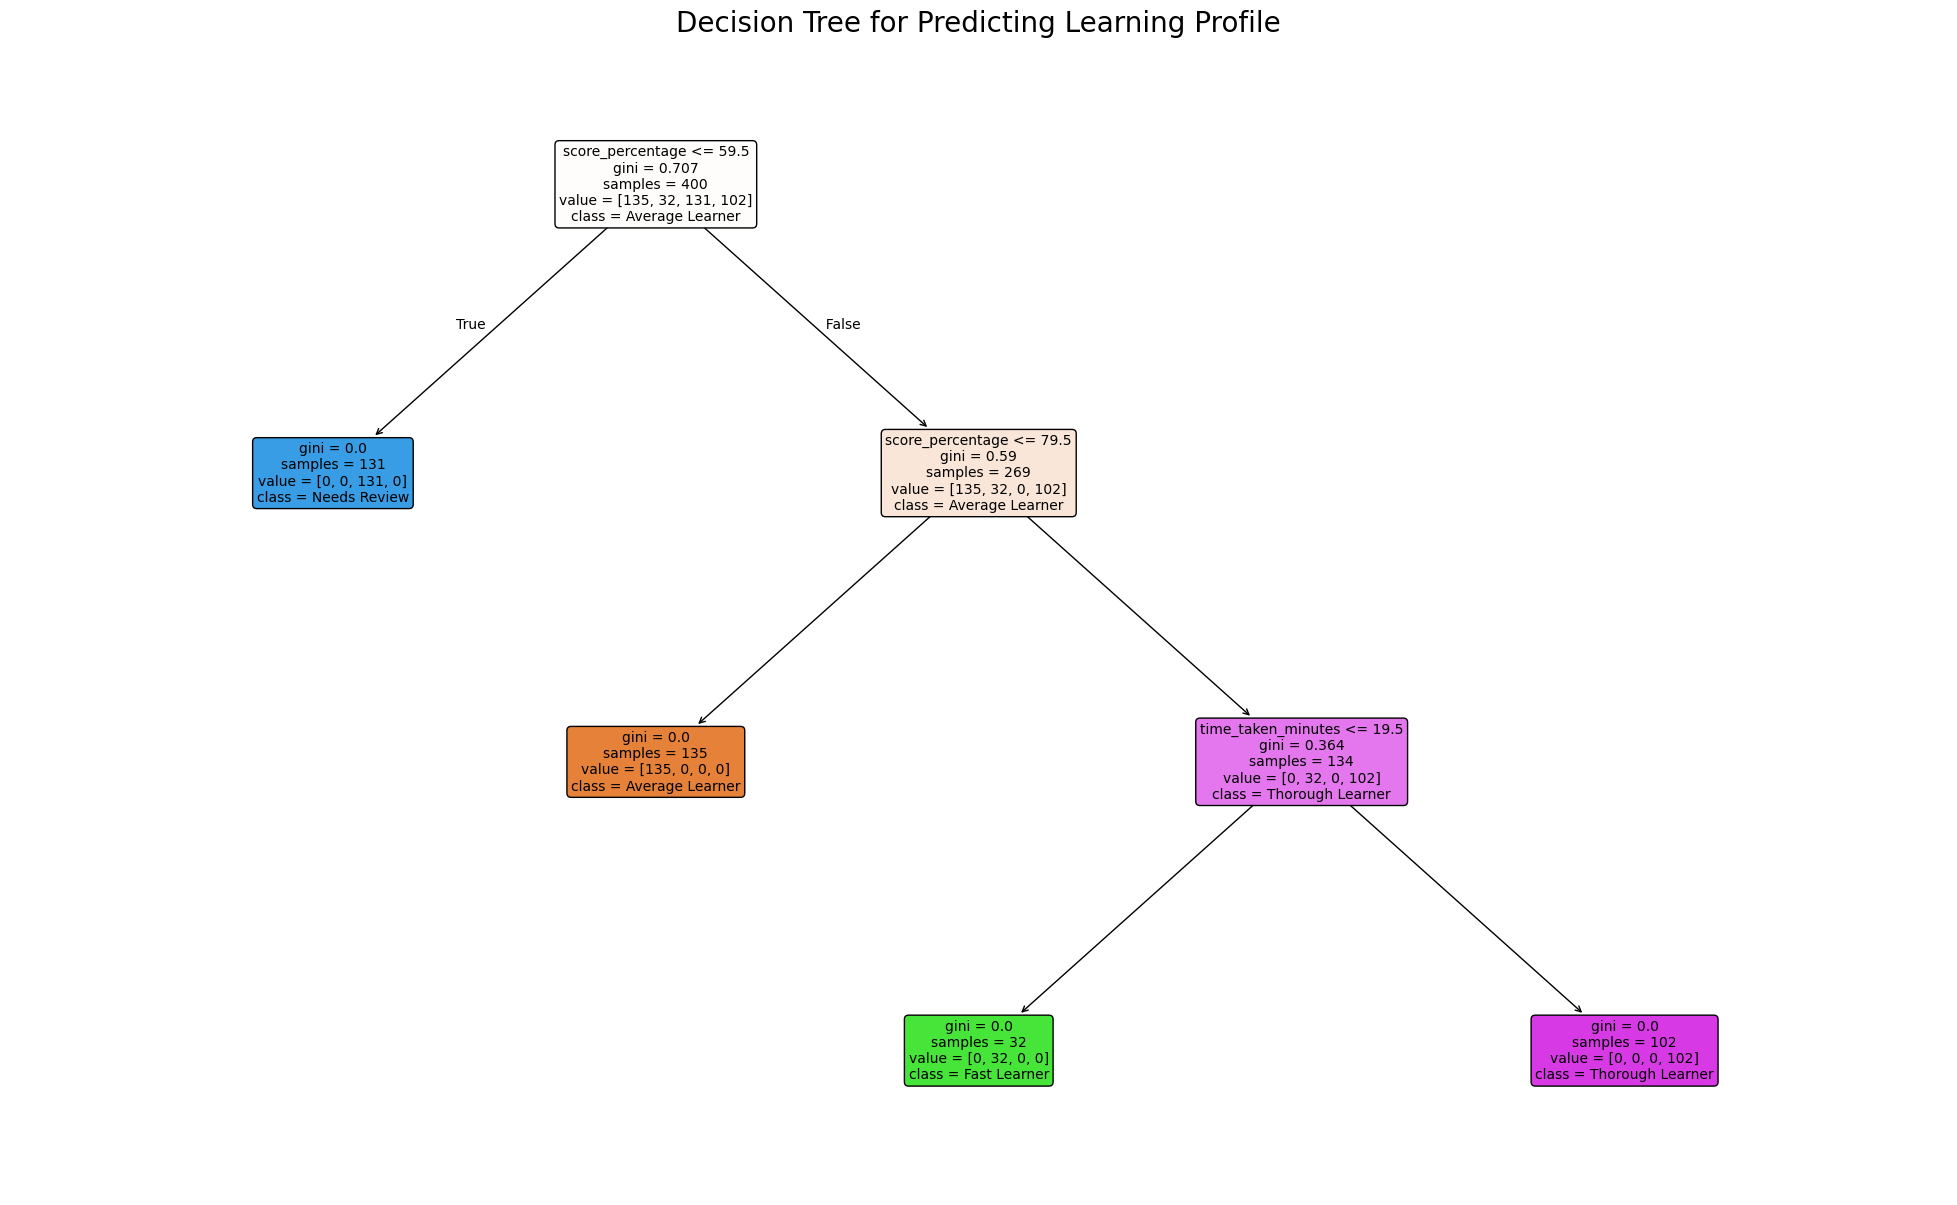


--- Saving the final model and encoders ---
All artifacts saved successfully in: ../Models/Quiz_Analysis


In [1]:
# 1. IMPORTING LIBRARIES
# ---------------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import joblib
import os

# ---------------------------------
# 2. LOADING THE DATASET
try:
    df = pd.read_csv('../Datasets/Quiz_Analysis/synthetic_quiz_data.csv')
    print("'synthetic_quiz_data.csv' dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'synthetic_quiz_data.csv' not found. Please ensure it's in the correct directory.")
    exit()

# ---------------------------------
# 3. DATA PREPROCESSING
print("\n--- Preprocessing the Data ---")

# Define features (X) and target (y)
features = ['score_percentage', 'time_taken_minutes', 'difficulty_level']
target = 'learning_profile'

X = df[features]
y = df[target]

# Encode the categorical feature ('difficulty_level') using OneHotEncoder
categorical_features = ['difficulty_level']
ohe = OneHotEncoder(handle_unknown='ignore')
X_encoded = ohe.fit_transform(X[categorical_features])

# Combine numerical and encoded categorical features
X_processed = pd.concat([
    X.drop(columns=categorical_features).reset_index(drop=True),
    pd.DataFrame(X_encoded.toarray(), columns=ohe.get_feature_names_out())
], axis=1)

# Encode the target variable ('learning_profile')
le = LabelEncoder()
y_processed = le.fit_transform(y)

print("Data preprocessing complete.")
print("\nProcessed feature columns:")
print(X_processed.columns.tolist())


# ---------------------------------
# 4. MODEL TRAINING
print("\n--- Training the Decision Tree Model ---")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42, stratify=y_processed)

# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_classifier.fit(X_train, y_train)

print("Model training complete.")

# ---------------------------------
# 5. MODEL EVALUATION
print("\n--- Evaluating the Model ---")

y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# ---------------------------------
# 6. VISUALIZING THE DECISION TREE
print("\n--- Visualizing the Learned Rules of the Decision Tree ---")

plt.figure(figsize=(25, 15))
plot_tree(
    dt_classifier,
    filled=True,
    feature_names=X_processed.columns.tolist(),
    class_names=le.classes_,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Predicting Learning Profile", fontsize=20)
plt.show()


# ---------------------------------
# 7. SAVING THE ARTIFACTS
print("\n--- Saving the final model and encoders ---")

model_dir = '../Models/Quiz_Analysis'
os.makedirs(model_dir, exist_ok=True)

# Define file paths
model_path = os.path.join(model_dir, 'model.joblib')
ohe_path = os.path.join(model_dir, 'one_hot_encoder.joblib')
le_path = os.path.join(model_dir, 'label_encoder.joblib')

# Save the artifacts
joblib.dump(dt_classifier, model_path)
joblib.dump(ohe, ohe_path)
joblib.dump(le, le_path)

print(f"All artifacts saved successfully in: {model_dir}")